In [1]:
import numpy as np
import matplotlib.pyplot as plt
import allantools
from matplotlib import rc
 

rc('font',**{'family':'sans-serif','sans-serif':['Fira Sans'],'size':14,'style':'normal'})
rc('text', usetex=False)


BLUE = 'xkcd:pastel blue'
RED = 'xkcd:pastel red'
GREEN = 'xkcd:pastel green'
YELLOW ='xkcd:pastel yellow'
PURPLE = 'xkcd:pastel purple'
DBLUE = 'xkcd:light navy blue'
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=[BLUE, RED, GREEN, YELLOW,PURPLE,DBLUE])

c = 3e8
f0 =429e12
h_const = 6.626e-34

def acc_noise(f):
    S_base = 1.74e-15
    S_acc =  1e-18/f+S_base
    return S_acc

def doppler_noise(f):
    S_base = 1.74e-15
    S_acc =  1e-18/f+S_base
    return S_acc/(2*np.pi*f*c)

def doppler_noise_PSD(f):

    return doppler_noise(f)**2

def spin_echo_Hf(f,T):
    return 4/(np.pi*f)**2*np.sin(np.pi*f*T/2)**4

Text(0, 0.5, '$S_a$ [m$^2$/s$^4$/Hz]')

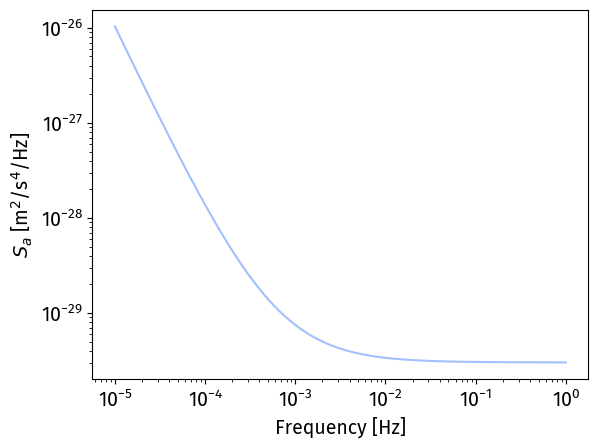

In [2]:

f = np.logspace(-5,0,10000)

plt.plot(f,acc_noise(f)**2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency [Hz]')
plt.ylabel('$S_a$ [m$^2$/s$^4$/Hz]')

(1.0000000000000001e-50, 1.0000000000000001e-34)

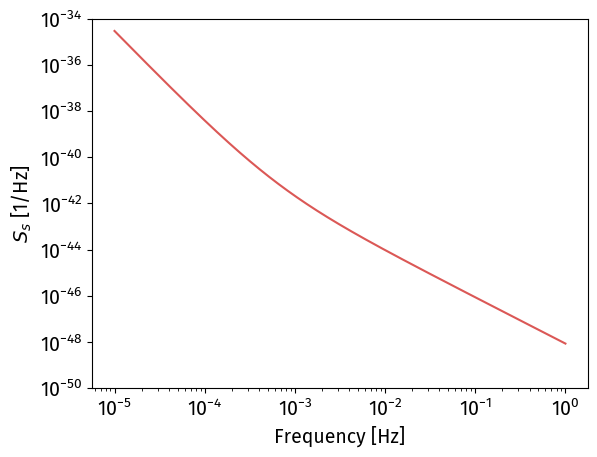

In [3]:


f = np.logspace(-5,0,10000)

plt.plot(f,acc_noise(f)**2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency [Hz]')
plt.ylabel('$S_a$ [m$^2$/s$^4$/Hz]')


plt.plot(f,doppler_noise(f)**2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency [Hz]')
plt.ylabel('$S_s$ [1/Hz]')


# plt.plot(f,np.sqrt(doppler_noise_PSD(f)*spin_echo_Hf(f,100)))
# plt.xscale('log')
# plt.yscale('log')
# plt.xlabel('Frequency [Hz]')
# plt.ylabel('$S_s$ [1/$\sqrt{\mathrm{Hz}}$]')

plt.ylim([1e-25**2,1e-17**2])

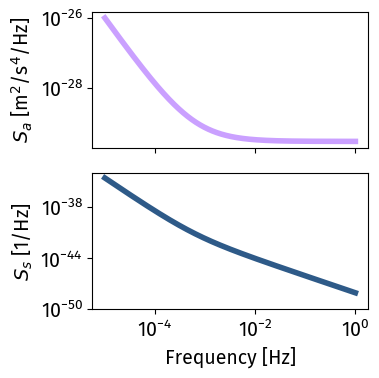

In [4]:
fig, axs = plt.subplots(2, 1, sharex=True, figsize=(4, 4))

# --- Acceleration noise ---
axs[0].plot(f, acc_noise(f)**2,linewidth = 4,color = PURPLE)
axs[0].set_yscale('log')
axs[0].set_ylabel(r'$S_a$ [m$^2$/s$^4$/Hz]')
# axs[0].set_ylim([1e-25**2, 1e-17**2])

# --- Doppler noise ---
axs[1].plot(f, doppler_noise(f)**2,linewidth = 4,color = DBLUE)
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_xlabel('Frequency [Hz]')
axs[1].set_ylabel(r'$S_s$ [1/Hz]')
axs[1].set_ylim([1e-25**2, 1e-17**2])



plt.tight_layout()

plt.savefig('plots/acceleration_noise.pdf')

Text(0.5, 0, 'Frequency [Hz]')

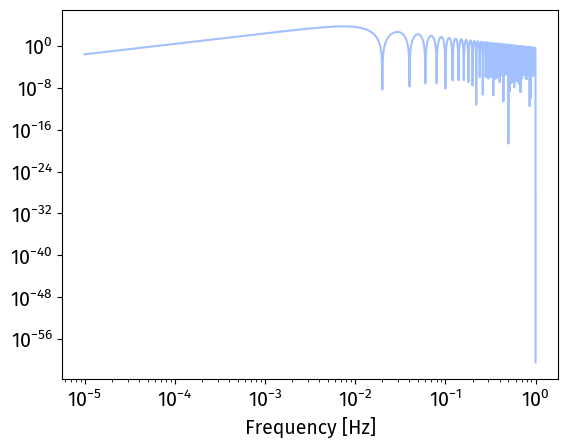

In [5]:
plt.plot(f,spin_echo_Hf(f,100))
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Frequency [Hz]')

In [6]:
def doppler_noise_PSD(f):

    return doppler_noise(f)**2

def timeseries_from_psd(Sx, fs, T):
    """
    Generate a real time series x(t) with one-sided PSD Sx(f).

    Parameters
    ----------
    Sx : callable
        One-sided PSD function Sx(f) [units^2 / Hz]
    fs : float
        Sampling frequency [Hz]
    T : float
        Total duration [s]

    Returns
    -------
    t : ndarray
        Time array
    x : ndarray
        Time series
    """

    N = int(T * fs)
    df = fs / N

    # positive frequency bins
    freqs = np.fft.rfftfreq(N, d=1/fs)

    # Fourier coefficients
    Xf = np.zeros(len(freqs), dtype=complex)

    # DC component
    Xf[0] = 0.0

    # positive frequencies (excluding Nyquist)
    for k in range(1, len(freqs) - 1):
        sigma = np.sqrt(0.5 * Sx(freqs[k]) * df)
        Xf[k] = sigma * (np.random.randn() + 1j*np.random.randn())

    # Nyquist frequency (real)
    if N % 2 == 0:
        Xf[-1] = np.sqrt(Sx(freqs[-1]) * df) * np.random.randn()

    # inverse FFT
    x = np.fft.irfft(Xf, n=N)
    t = np.arange(N) / fs

    return t, x



In [7]:
t,noise = timeseries_from_psd(doppler_noise_PSD,1,100*100000)



-2.423933233476902e-17


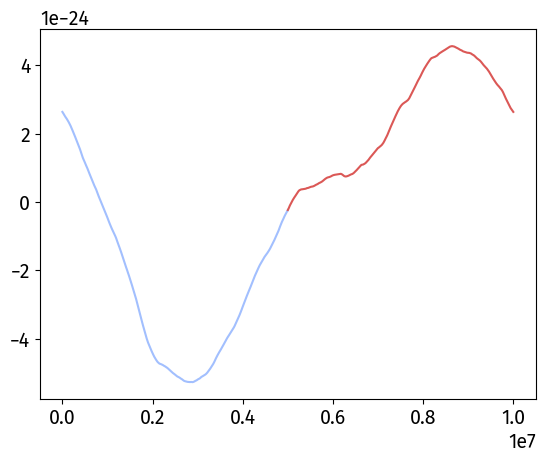

In [8]:
plt.plot(t[0:int(len(t)/2)],noise[0:int(len(t)/2)])
plt.plot(t[int(len(t)/2):-1],noise[int(len(t)/2):-1])
print(np.sum(noise[0:int(len(t)/2)])-np.sum(noise[int(len(t)/2):-1]))

In [9]:
bins = noise.reshape(1000, -1)

In [10]:
s = []
bins_spin_echo = []
for meas in bins:
    meas_new = []
    meas_new = -meas
    for i in range(int(len(meas)/2)):
        meas_new[i] = meas[i]
    bins_spin_echo.append(meas_new)
    s.append(np.sum(meas_new)/100)
    

In [11]:
def laser_noise(t,T,P,eta,delta):
    avar =  3*(1/(2*np.pi*f0))**2*(1/(T*t))*np.sqrt(h_const*f0*delta/(P*eta))
    return np.sqrt(avar)
    
def QPN(t,T,N):
    avar =  (1/(2*np.pi*f0))**2*(1/(T*t))*1/N
    return np.sqrt(avar)
    

In [12]:
def adevffd(frac_freq_diff,t_ramsey,t_dead,N,C):
    r = 1/(t_ramsey+t_dead)
    #(t2, ad, ade, adn) = allantools.oadev(frac_freq_diff/f0, rate=r, data_type="freq", taus=t)
    (t2, ad, ade, adn) = allantools.oadev(frac_freq_diff, rate=r, data_type="freq")
    plt.plot(t2,ad)
    plt.xscale('log')
    plt.yscale('log')
    return (t2,ad,ade)

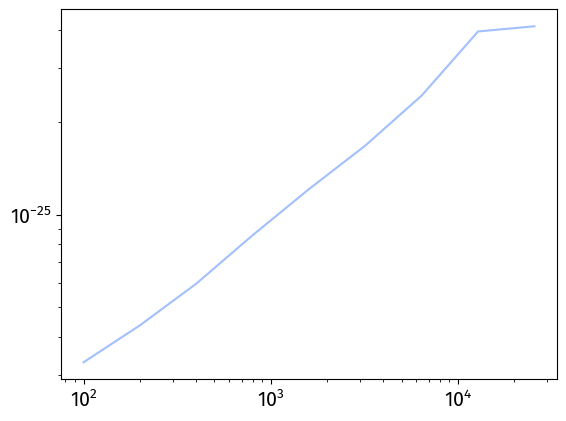

In [13]:
t2,ad,ade = adevffd(s,100,0,1e7,1)

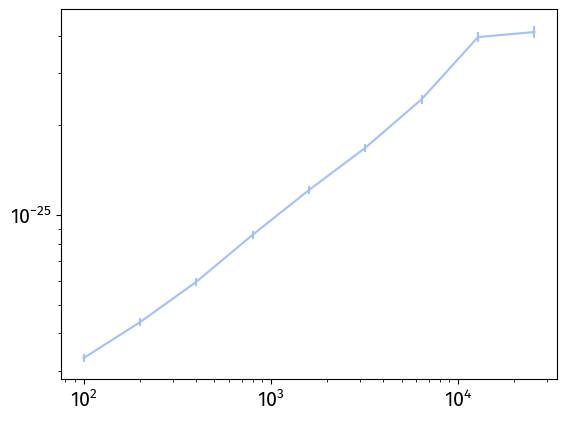

In [14]:
plt.errorbar(t2,ad,ade)
plt.yscale('log')
plt.xscale('log')

In [75]:
from scipy.optimize import curve_fit
def power_law(x, A, alpha):
    return A * x**alpha


x = np.array(t2)
y = np.array(ad)

logx = np.log(x)
logy = np.log(y)


popt, pcov = curve_fit(
    power_law,
    t2,
    ad,
    sigma=ade,          # optional
    absolute_sigma=True  # if yerr is real uncertainty
    
)

A, alpha = popt
A_err, alpha_err = np.sqrt(np.diag(pcov))


alpha, logA = np.polyfit(logx, logy, 1)
A = np.exp(logA)

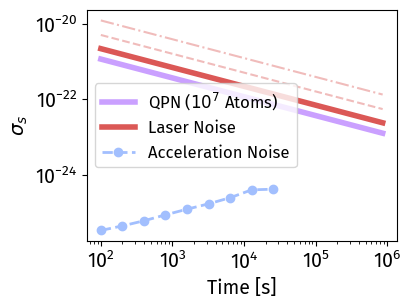

In [21]:
t = np.linspace(100,86400*10,10000)

T = 100
N = 1e7
P = 200e-9
delta = 10e-3
eta = 1

plt.figure(figsize = (4,3))
plt.plot(t,QPN(t,T,N),color = PURPLE, label = 'QPN ($10^7$ Atoms)',linewidth = 4)

plt.plot(t,laser_noise(t,T,P,eta,delta),color = RED,label = 'Laser Noise',linewidth = 4)

plt.plot(t2,ad, linewidth = 2, marker = 'o', color = BLUE,linestyle = '--', label = 'Acceleration Noise')
P = 20e-9
delta = 20e-3
eta = 0.7
plt.plot(t,laser_noise(t,T,P,eta,delta),color = RED,linestyle = '--',alpha = 0.4)
P = 1.2e-9
delta = 30e-3
eta = 0.5
plt.plot(t,laser_noise(t,T,P,eta,delta),color = RED,linestyle = '-.',alpha = 0.4)
# plt.plot(t, A*t**alpha,'--')
plt.yscale('log')
plt.xscale('log')
plt.legend(fontsize = 12,loc = 'center left')
plt.xlabel('Time [s]')
plt.ylabel('$\sigma_s$')
plt.savefig('plots/adev_noise_sources.pdf',bbox_inches = 'tight')